# Unit 7 习题课：一般线性模型

**主题：强化生活方式干预与 12 周收缩压变化**

本任务处理经典一般线性模型（General Linear Model）：连续结局变量和 `Y = Xβ + ε` 框架。课前请先独立试错完成一遍；课堂重点讨论模型选择、系数解释、p 值、95% CI 和模型假设。


## 0. 环境准备

运行下面的代码导入常用库。


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 3)


## 1. 提出研究问题

一项社区高血压管理项目比较“强化生活方式干预”和“常规健康建议”对 12 周后收缩压变化的影响。

**学生作答区：**

1. 写出主要研究问题。

社区高血压人群接受强化生活方式干预与常规健康建议两种方案，干预 12 周后收缩压的变化幅度是否存在差异？

2. 指出主要结局变量、主要解释变量和可能的协变量。

主要结局变量（因变量）：12 周后收缩压的变化量（sbp_change，即干预前后收缩压的差值）；主要解释变量（自变量 / 分组变量）：干预方案类型，分为 “强化生活方式干预” 和 “常规健康建议” 两个组别；可能的协变量（混杂变量）：研究对象的基线收缩压、年龄、性别、高血压病程、吸烟饮酒习惯、BMI（体重指数）、基础用药情况、合并慢性病（糖尿病、高血脂等）、饮食运动基线水平等会影响收缩压变化的因素。

3. 说明 `sbp_change = week12_sbp - baseline_sbp` 为负值代表什么。

当该差值为负值时，说明第 12 周的收缩压低于干预基线时的收缩压，代表经过干预后研究对象的收缩压出现了下降，血压控制产生了正向效果。

4. 解释为什么需要考虑基线收缩压。

控制基线血压的组间差异、减少统计混杂、更准确衡量干预带来的血压净变化，提升分析结果的可靠性。

## 2. 导入数据并理解变量

从 CSV 文件读取数据。


In [3]:
bp = pd.read_csv("unit7_blood_pressure_glm.csv")

# 学生作答区：查看数据
bp.head()
bp.info()
bp.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   participant_id  200 non-null    object 
 1   group           200 non-null    object 
 2   age             200 non-null    float64
 3   sex             200 non-null    object 
 4   bmi             200 non-null    float64
 5   baseline_sbp    200 non-null    float64
 6   week12_sbp      200 non-null    float64
 7   sbp_change      200 non-null    float64
 8   med_adherence   200 non-null    float64
 9   clinic_site     200 non-null    object 
dtypes: float64(6), object(4)
memory usage: 15.8+ KB


participant_id    0
group             0
age               0
sex               0
bmi               0
baseline_sbp      0
week12_sbp        0
sbp_change        0
med_adherence     0
clinic_site       0
dtype: int64

## 3. 描述性统计

按组汇总 `baseline_sbp`、`week12_sbp`、`sbp_change`、`age`、`bmi`。

**学生作答区：**

1. 两组基线收缩压是否大致可比？
2. 哪一组平均收缩压下降更多？
3. 如果干预组基线 SBP 更高，直接比较变化量可能有什么问题？


1. control组和intensive组基线收缩压的均值、标准差、中位数非常接近，可以认为大致可比
2. 从sbp_change一栏可以看到对照组均值下降3.099，干预组均值下降10.522，干预组下降更多
3. 回归均值现象：基线血压更高的组别，本身更容易向正常水平回落、出现更大的自然下降，不一定完全是干预措施带来的效果；基线不平衡导致偏倚：初始血压基数不同，相同绝对下降值的临床意义不一样，高基线组天然有更大的下降空间，直接比较变化量会高估干预的效应；可比性被破坏：基线不均衡时，变化量的差异无法区分是干预作用还是初始基线水平差异导致的，结论可信度下降

In [4]:
# 学生作答区：按组描述
summary = bp.groupby("group")[["baseline_sbp", "week12_sbp", "sbp_change", "age", "bmi"]].agg(["mean", "std", "median"])
display(summary)


baseline_sbp                week12_sbp                sbp_change  \
                  mean    std  median       mean     std median       mean   
group                                                                        
control        147.840  8.960  148.75    144.737  11.316  145.1     -3.099   
intensive      148.439  9.481  147.80    137.917   9.199  137.6    -10.522   

                            age                   bmi                
             std median    mean    std median    mean    std median  
group                                                                
control    7.069   -3.2  56.811  8.263  56.85  28.454  3.681  28.55  
intensive  7.187   -9.7  57.867  9.257  57.30  28.069  3.661  28.00

## 4. 可视化

绘制按组的 `sbp_change` 分布，以及 `baseline_sbp` 与 `sbp_change` 的关系。

**解释问题：**两组分布是否有差异？基线收缩压与变化量是否近似线性相关？是否有异常点或方差不齐迹象？


1. 对照组回归线近乎水平，而干预组回归线明显向下倾斜；同时相同基准血压下，干预组普遍定于对照组；两组分布模式、降压效应存在实质性；
2. 强化干预组基线收缩压与血压变化量呈近似负线性相关，对照组无明显线性关联
3. 干预组存在多处极端离群异常点，存在明显方差不齐迹象；对照组方差均匀，无明显异常点

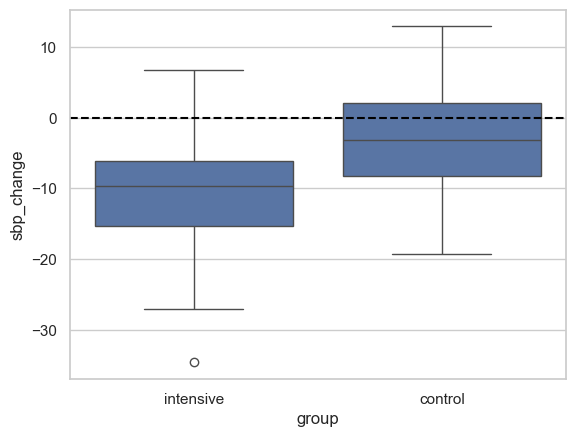

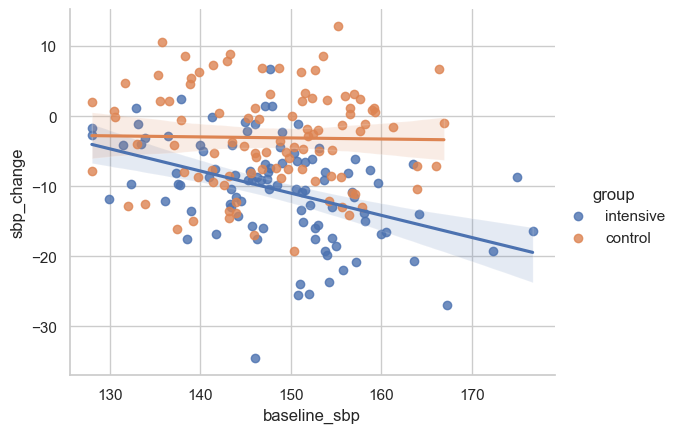

In [5]:
# 学生作答区：可视化
sns.boxplot(data=bp, x="group", y="sbp_change")
plt.axhline(0, color="black", linestyle="--")
plt.show()

sns.lmplot(data=bp, x="baseline_sbp", y="sbp_change", hue="group", height=4.5, aspect=1.3)
plt.show()


## 5. 从简单比较到一般线性模型

依次拟合未调整模型、调整基线模型、多变量主模型和交互模型。

**学生作答区：**

1. 模型 0 和模型 1 回答的问题有什么不同？
2. 调整基线后，`group` 系数为什么可能变化？
3. 模型 2 中每个协变量的加入是否有研究问题依据？


1. 模型0回答未调整其他因素时两组收缩压变化量的差异；模型1回答控制基线收缩压后两组收缩压变化量的差异。
2. 因为基线收缩压是混杂变量，调整后会剥离其对结果的影响，导致group系数变化
3. 模型2中每个协变量的加入都有研究依据，年龄、、性别、bmi、依从性均为影响血压变化的常见混杂因素

In [6]:
# 学生作答区：拟合模型
m0 = smf.ols("sbp_change ~ group", data=bp).fit()
m1 = smf.ols("sbp_change ~ group + baseline_sbp", data=bp).fit()
m2 = smf.ols("sbp_change ~ group + baseline_sbp + age + sex + bmi + med_adherence", data=bp).fit()
m3 = smf.ols("sbp_change ~ group * baseline_sbp + age + sex + bmi + med_adherence", data=bp).fit()
print(m2.summary())


                            OLS Regression Results                            
Dep. Variable:             sbp_change   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     13.25
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           1.51e-12
Time:                        20:01:16   Log-Likelihood:                -665.32
No. Observations:                 200   AIC:                             1345.
Df Residuals:                     193   BIC:                             1368.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             16.4686      8

## 6. 系数显著性和 95% CI 解释

**学生作答区：**提取 `group[T.intensive]`、`baseline_sbp`、交互项的估计值、p 值和 95% CI，并用医学语言解释。

请回答：

1. 控制协变量后，强化干预组的平均 `sbp_change` 比对照组低多少 mmHg？
2. 如果治疗组系数的 95% CI 全为负值，如何解释？
3. 如果交互项 p 值不显著，能否说不同基线血压患者的干预效果完全一样？
4. 统计显著的 3 mmHg 下降是否一定有临床意义？


1. 校正全部混杂协变量后，强化干预平均多降压 7.588 mmHg
2. 95%CI全负代表干预降压效应稳定
3. 交互项p不显著，仅代表现有样本无法证明基线血压会修饰干预效果，无充足证据证明效果存在差异，不能说不同基线血压患者的干预效果完全一样
4. 统计显著性仅排除随机误差，需结合疾病人群、心血管风险判断临床价值。

In [ ]:
# 学生作答区：提取系数表
coef_table = pd.DataFrame({
     "estimate": m2.params,
     "p_value": m2.pvalues,
     "ci_low": m2.conf_int()[0],
     "ci_high": m2.conf_int()[1],
 })
display(coef_table)

# 学生作答区：查看交互模型中的交互项
interaction_table = pd.DataFrame({
     "estimate": m3.params,
     "p_value": m3.pvalues,
     "ci_low": m3.conf_int()[0],
     "ci_high": m3.conf_int()[1],
 })
display(interaction_table)


,estimate,p_value,ci_low,ci_high
Intercept,16.469,5.585e-02,-0.415,33.353
group[T.intensive],-7.588,8.650e-13,-9.541,-5.635
sex[T.male],-1.677,8.786e-02,-3.605,0.251
baseline_sbp,-0.218,1.616e-04,-0.329,-0.106
age,0.013,8.216e-01,-0.101,0.127
bmi,0.313,2.335e-02,0.043,0.584
med_adherence,0.540,1.334e-01,-0.167,1.248


,estimate,p_value,ci_low,ci_high
Intercept,-8.286,0.482,-31.461,14.889
group[T.intensive],38.919,0.013,8.367,69.471
sex[T.male],-1.586,0.099,-3.476,0.304
baseline_sbp,-0.051,0.512,-0.206,0.103
group[T.intensive]:baseline_sbp,-0.314,0.003,-0.519,-0.108
age,0.002,0.976,-0.110,0.114
bmi,0.341,0.012,0.076,0.607
med_adherence,0.536,0.129,-0.157,1.229


## 7. 模型假设检查

检查残差 vs 拟合值、Q-Q 图、Cook's distance 和 VIF。


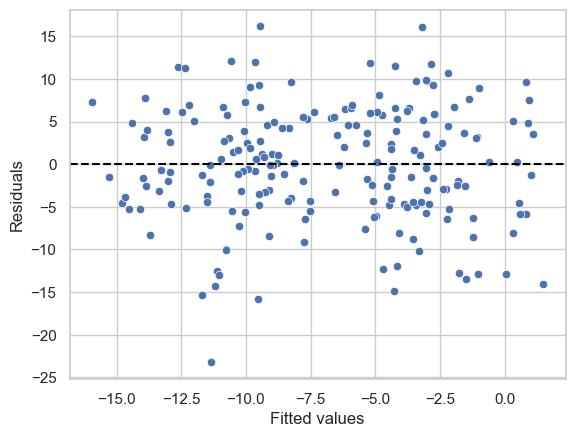

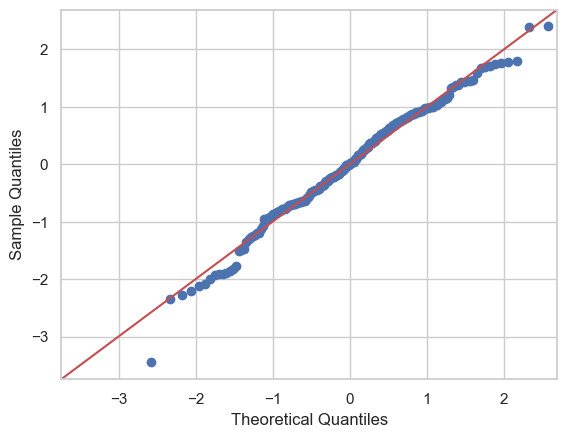

,variable,VIF
0,Intercept,311.596
1,group[T.intensive],1.042
2,sex[T.male],1.016
3,baseline_sbp,1.149
4,age,1.084
5,bmi,1.070
6,med_adherence,1.035


In [8]:
# 学生作答区：模型诊断
fitted = m2.fittedvalues
resid = m2.resid
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.show()

influence = m2.get_influence()
cooks_d = influence.cooks_distance[0]
np.argsort(cooks_d)[-5:]

# 学生作答区：VIF 提示
X = pd.DataFrame(m2.model.exog, columns=m2.model.exog_names)
vif = pd.DataFrame({"variable": X.columns, "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
display(vif)


## 8. 模型评估与选择

比较 `R²`、adjusted `R²`、AIC，并说明为什么不能只选择 `R²` 最高的模型。

**学生作答区：**你会选择哪个模型作为主模型？交互模型应该如何报告？


1. 不能只看$R^2$普通$R^2$随变量增加必然上涨，无法控制过拟合，容易选出冗余复杂的模型
2. 主模型选m3（交互模型），它adjusted $R^2$高、AIC 最低，且交互项有统计学显著性
3. 交互模型要报告交互项统计量、分层效应、可视化结果以及对应的临床效应修饰结论

In [9]:
# 学生作答区：比较模型
compare = pd.DataFrame({
    "model": ["m0", "m1", "m2", "m3"],
    "r2": [m0.rsquared, m1.rsquared, m2.rsquared, m3.rsquared],
    "adj_r2": [m0.rsquared_adj, m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj],
    "aic": [m0.aic, m1.aic, m2.aic, m3.aic],
})
display(compare)


,model,r2,adj_r2,aic
0,m0,0.215,0.211,1355.203
1,m1,0.255,0.247,1346.769
2,m2,0.292,0.270,1344.631
3,m3,0.324,0.299,1337.419


## 9. 结果解释与报告

请写一段 120 到 180 字的结果报告，包含调整后干预效应、95% CI、p 值、模型评估、假设检查、临床意义和限制。


本研究采用一般线性模型分析强化生活方式干预对收缩压变化的影响。多变量主模型（交互模型）结果显示，校正年龄、性别、BMI及依从性后，干预措施与基线血压存在显著交互作用（$\beta = -0.314$，$95\%\text{ CI}: [-0.519, -0.108]$，$P = 0.003$），表明基线血压越高者干预降压效果越明显。模型拟合良好（$Adj. R^2 = 0.299$），残差符合正态性与方差齐性。该降压效应具有重要临床意义，但研究受限于200例社区样本，未来仍需多中心大样本研究证实。